In [1]:
import pandas as pd

# Load datasets
crop = pd.read_csv("../data/raw/crop_production.csv")
weather = pd.read_csv("../data/raw/GlobalLandTemperaturesByCountry.csv")
logistics = pd.read_csv("../data/raw/logistics.csv")  # name might differ, adjust

# Show first rows
crop.head(), weather.head(), logistics.head()

(                    State_Name District_Name  Crop_Year       Season  \
 0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
 1  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
 2  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
 3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
 4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
 
                   Crop    Area  Production  
 0             Arecanut  1254.0      2000.0  
 1  Other Kharif pulses     2.0         1.0  
 2                 Rice   102.0       321.0  
 3               Banana   176.0       641.0  
 4            Cashewnut   720.0       165.0  ,
            dt  AverageTemperature  AverageTemperatureUncertainty Country
 0  1743-11-01               4.384                          2.294   Åland
 1  1743-12-01                 NaN                            NaN   Åland
 2  1744-01-01                 NaN                           

In [2]:
print("CROP DATA")
print(crop.info())

print("\nWEATHER DATA")
print(weather.info())

print("\nLOGISTICS DATA")
print(logistics.info())

CROP DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB
None

WEATHER DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  object 
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545

In [3]:
weather_india = weather[weather["Country"] == "India"]
weather_india = weather_india[["dt", "AverageTemperature"]]
weather_india.head()

,dt,AverageTemperature
243695,1796-01-01,17.044
243696,1796-02-01,19.193
243697,1796-03-01,22.319
243698,1796-04-01,27.233
243699,1796-05-01,30.035


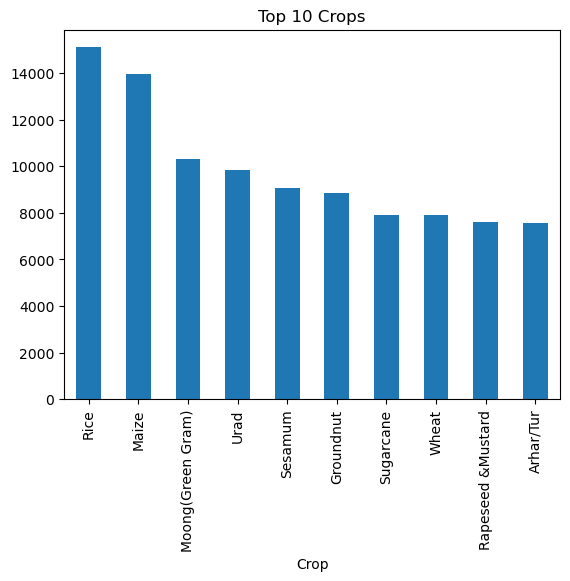

In [4]:
import matplotlib.pyplot as plt

crop["Crop"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Crops")
plt.show()

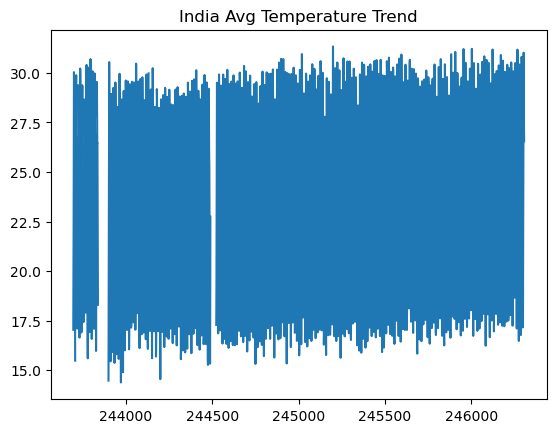

In [5]:
weather_india["AverageTemperature"].plot()
plt.title("India Avg Temperature Trend")
plt.show()

In [6]:
# Convert to datetime first
logistics["delivery_time_hours"] = pd.to_datetime(
    logistics["delivery_time_hours"], errors="coerce"
)

logistics["expected_time_hours"] = pd.to_datetime(
    logistics["expected_time_hours"], errors="coerce"
)

# Convert datetime to hours (since midnight)
logistics["delivery_time_hours"] = (
    logistics["delivery_time_hours"].dt.hour +
    logistics["delivery_time_hours"].dt.minute / 60 +
    logistics["delivery_time_hours"].dt.second / 3600
)

logistics["expected_time_hours"] = (
    logistics["expected_time_hours"].dt.hour +
    logistics["expected_time_hours"].dt.minute / 60 +
    logistics["expected_time_hours"].dt.second / 3600
)

logistics[["delivery_time_hours", "expected_time_hours"]].head()


,delivery_time_hours,expected_time_hours
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [7]:
logistics["Delivery_Delay"] = (
    logistics["delivery_time_hours"] - logistics["expected_time_hours"]
)

logistics["Delivery_Delay"].describe()


count    25000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Delivery_Delay, dtype: float64

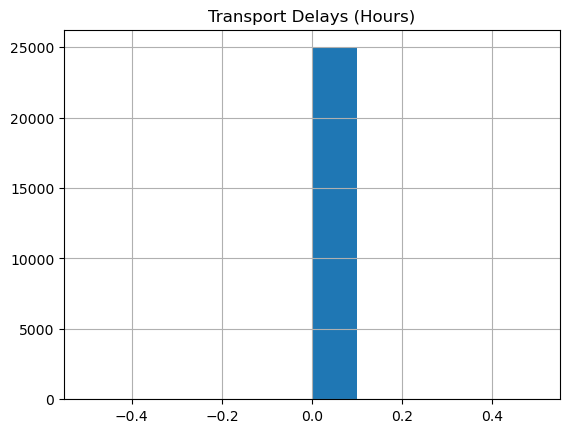

In [8]:
logistics["Delivery_Delay"].hist()
plt.title("Transport Delays (Hours)")
plt.show()
